In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import CustomModules.util as util
import plotly.express as px
import torch.nn as nn
import torch
import CustomModules.A_CAE as A_CAE
import CustomModules.A_AE as A_AE
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_s_curve

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [70]:
s_data, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=0)
s_data_test, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=1)
util.plot3d([(s_data, "S-Curve Dataset")], title="Double Torus") 

In [95]:
torus_data = util.generate_torus(10000)
torus_data_test = util.generate_torus(10000)
util.plot3d([(torus_data, "torus data")], title="Double Torus")

In [97]:
X_train = torch.tensor(torus_data, dtype=torch.float32)
X_test = torch.tensor(torus_data_test, dtype=torch.float32)
X_loader_train = torch.utils.data.DataLoader(X_train, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_test, batch_size=1024, shuffle=True)

In [58]:
ae = A_AE.AE(3,15,3)

In [ ]:
A_AE.train_ae(num_epochs=1000, x_train_loader=X_loader_train, network=ae, device=device)

In [187]:



cae = A_CAE.CAE(m=3, l=10, d=3, outer_structure=[10, 10], inner_structure=[10, 10], predictor_structure=[10, 10], chart_amount=8, activation_outer=nn.Identity(), activation_inner=nn.Tanh())
A_CAE.pre_train_cae(num_epochs=50, x_train=X_train, network=cae, device = device)


diag = A_CAE.train_cae(num_epochs=30, x_train_loader=X_loader_train, network=cae, device=device, lr=1e-2)

D:\Documents_D\Geometric-Deep-Learning\src\CustomModules\A_CAE.py:96: UserWarning: Using a target size (torch.Size([3])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss += F.mse_loss(x_recon, x[i]) + F.mse_loss(z_latent, torch.zeros_like(z_latent)+0.5) - torch.log(network.predict(x)[i, i] + 1e-8)
100%|██████████| 30/30 [00:10<00:00,  2.95it/s]


In [188]:

def reconstruct(model_name, data):
    if model_name == "ae":
        ae.to("cpu")
        reconstructed = ae.decode(ae.encode(data)).detach().numpy()
        reconstructed.shape
        return reconstructed
    if model_name == "cae":
        cae.to("cpu")
        probabilities = cae.predict(data)
        alpha = torch.argmax(probabilities, dim=1)
        reconstructed = cae.encode_decode(data).detach().numpy()
        return reconstructed, alpha
reconstructed, alpha = reconstruct("cae", X_train[0:10000])
util.plot3d([(reconstructed, "reconstructed")], title="Double Torus", color=[alpha.detach().numpy()])

In [180]:
with torch.no_grad():
    probabilities = cae.predict(X_test)
    alpha = torch.argmax(probabilities, dim=1)

util.plot3d(
    [(X_test, "original torus")],
    color=[alpha.numpy()]
)

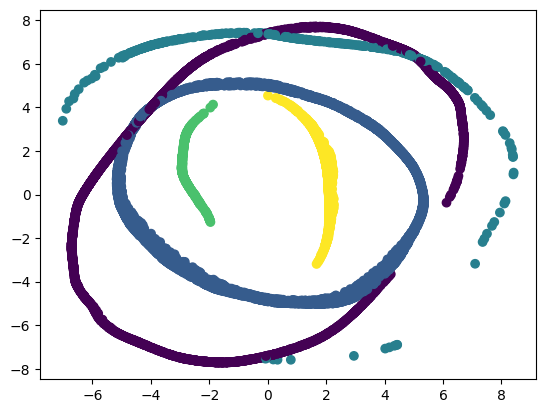

In [185]:
probabilities = cae.predict(X_test)
alpha = torch.argmax(probabilities, dim=1)
middle = cae.encode(X_test)
latent = cae.chart_multi_encode(middle, alpha).detach().numpy()
plt.scatter(latent[:, 0], latent[:, 1], c=alpha.detach().numpy())

In [177]:
probabilities = cae.predict(X_test)
alpha = torch.argmax(probabilities, dim=1)
middle = cae.encode(X_test)
latent = cae.chart_multi_encode(middle, alpha).detach().numpy()
util.plot3d([(latent, "latent"),], title="Double Torus Latent Space")